# Monoculture Treated - Mechanical Automatic Modeling
Decode processed data, fit treated model zoo, and run sensitivity/uncertainty analysis.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

  Activating project at `c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package`
Precompiling packages...
              ✗ MechanicalAutomaticModeling
  0 dependencies successfully precompiled in 27 seconds. 490 already precompiled.

The following 1 direct dependency failed to precompile:

MechanicalAutomaticModeling 

Failed to precompile MechanicalAutomaticModeling [4c59f1b9-0350-4485-8fe5-0c8559674061] to "C:\\Users\\elbak\\.julia\\compiled\\v1.12\\MechanicalAutomaticModeling\\jl_169C.tmp".
ERROR: LoadError: ArgumentError: Package MechanicalAutomaticModeling does not have BlackBoxOptim in its dependencies:
- Note that the following manifests in the load path were resolved with a different
  julia version, which may be the cause of the error. Try to re-resolve them in the
  current version, or consider deleting them if that fails:
    C:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\Manifest.toml (

In [2]:
using CSV, DataFrames, Plots, Dates, Statistics, DifferentialEquations
include(joinpath(@__DIR__, "..", "src", "MechanicalAutomaticModeling.jl"))
using .MechanicalAutomaticModeling
using GrowthParameterEstimation

In [3]:
condition = "monoculture_treated"
decoded = MechanicalAutomaticModeling.IOUtils.decode_condition_dataframe(condition; start=@__DIR__)
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
decoded_path = joinpath(out.csv, "$(condition)_automatic_decoded.csv")
CSV.write(decoded_path, decoded)
MechanicalAutomaticModeling.IOUtils.write_manifest_row(condition=condition, step="decode", outputs=[decoded_path], start=@__DIR__)
Text(repr(first(decoded, min(10, nrow(decoded)))))

10×9 DataFrame
 Row │ time     count    source_file                     condition            density  cell_line   dose     mix      replicate
     │ Float64  Float64  String                          String               String   String      Float64  String3  Int64
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     1.0  332.641  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     0.67  A4               1
   2 │     1.0  497.382  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     0.67  A5               2
   3 │     1.0  581.122  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     0.67  A6               3
   4 │     1.0  178.076  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     1.0   A1               1
   5 │     1.0  164.777  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive  

## API And Untreated Baseline Check
This notebook now inspects the installed GrowthParameterEstimation package API and loads the untreated best-fit baseline explicitly before any treated fitting step.

In [4]:
gpe_module_path = pathof(GrowthParameterEstimation)
gpe_source_dir = dirname(gpe_module_path)
gpe_source_files = filter(isfile, [
    gpe_module_path,
    joinpath(gpe_source_dir, "fitting.jl"),
    joinpath(gpe_source_dir, "analysis.jl"),
])
gpe_source_text = join(read.(gpe_source_files, String), "\n")

pipeline_api_summary = DataFrame(
    check = [
        "package_path",
        "has_default_config_symbol",
        "has_run_pipeline_symbol",
        "source_mentions_default_config",
        "source_mentions_run_pipeline",
    ],
    value = [
        string(gpe_module_path),
        string(isdefined(GrowthParameterEstimation, :default_config)),
        string(isdefined(GrowthParameterEstimation, :run_pipeline)),
        string(occursin("default_config", gpe_source_text)),
        string(occursin("run_pipeline", gpe_source_text)),
    ],
)

untreated_baseline = MechanicalAutomaticModeling.FitWorkflows.load_untreated_baseline(; start=@__DIR__)
untreated_baseline_summary = untreated_baseline === nothing ? DataFrame(
    key = ["status"],
    value = ["missing untreated baseline outputs"],
) : DataFrame(
    key = vcat(["model"], ["param_$(i)" for i in eachindex(untreated_baseline.params)]),
    value = vcat([untreated_baseline.model], string.(untreated_baseline.params)),
)

display(pipeline_api_summary)
untreated_baseline_summary

Row,check,value
,String,String
1,package_path,C:\\Users\\elbak\\.julia\\packages\\GrowthParameterEstimation\\NB9Qj\\src\\GrowthParameterEstimation.jl
2,has_default_config_symbol,true
3,has_run_pipeline_symbol,true
4,source_mentions_default_config,true
5,source_mentions_run_pipeline,true


Row,key,value
,String,String
1,model,logistic_growth
2,param_1,0.7473858776110882
3,param_2,3873.3816294744283


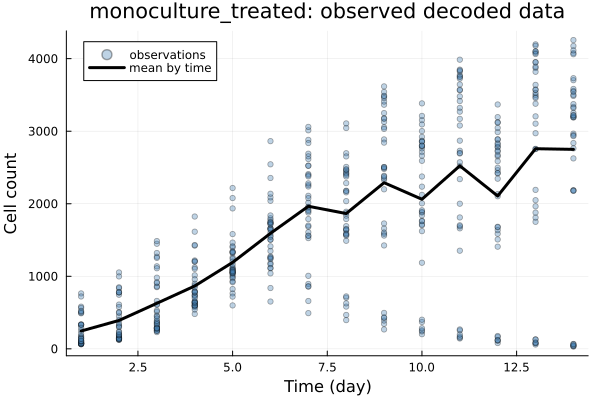

In [5]:
# Visualize decoded observations and their time-wise mean trend
obs_plot = scatter(
    decoded.time,
    decoded.count;
    alpha = 0.35,
    ms = 3,
    color = :steelblue,
    label = "observations",
    xlabel = "Time (day)",
    ylabel = "Cell count",
    title = "$(condition): observed decoded data",
    legend = :topleft,
)
time_means = combine(groupby(decoded, :time), :count => mean => :mean_count)
plot!(obs_plot, time_means.time, time_means.mean_count; lw = 3, color = :black, label = "mean by time")
display(obs_plot)

In [6]:
fit_artifacts = MechanicalAutomaticModeling.FitWorkflows.run_condition_fit!(
    decoded,
    condition;
    start=@__DIR__,
    untreated_baseline=untreated_baseline,
    )
Text(repr(first(fit_artifacts.ranking, min(10, nrow(fit_artifacts.ranking)))))

  Fitting hill_death_instantaneous at dose=0.67...
  Fitting one_stage_transit_linear_kill at dose=0.67...
  Fitting transit_hill_combined at dose=0.67...
  Fitting hill_death_instantaneous at dose=1.0...
  Fitting one_stage_transit_linear_kill at dose=1.0...
  Fitting transit_hill_combined at dose=1.0...
  Fitting hill_death_instantaneous at dose=1.47...
  Fitting one_stage_transit_linear_kill at dose=1.47...
  Fitting transit_hill_combined at dose=1.47...
  Fitting anchored_linear_kill at dose=0.67, cell=A2780Naive, density=20k...
  Fitting anchored_hill_kill at dose=0.67, cell=A2780Naive, density=20k...
  Fitting anchored_linear_kill at dose=1.0, cell=A2780Naive, density=20k...
  Fitting anchored_hill_kill at dose=1.0, cell=A2780Naive, density=20k...
  Fitting anchored_linear_kill at dose=1.47, cell=A2780Naive, density=20k...
  Fitting anchored_hill_kill at dose=1.47, cell=A2780Naive, density=20k...
  Fitting anchored_linear_kill at dose=0.67, cell=A2780Naive, density=30k...
  Fitti

10×7 DataFrame
 Row │ model                          dose     bic      ssr        params                             cell_line   density
     │ String                         Float64  Float64  Float64    String                             String      String
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ one_stage_transit_linear_kill     0.67  145.459  2.14263e5  [0.923782252473331, 9.9999993339…  pooled      pooled
   2 │ anchored_linear_kill              1.47  150.212  5.29672e5  (k_kill = 0.08419834379237304, r…  A2780Naive  30k
   3 │ hill_death_instantaneous          0.67  150.525  2.54815e5  [0.5668235117865584, 1410.559696…  pooled      pooled
   4 │ transit_hill_combined             0.67  150.737  2.14263e5  [0.9237816005430635, 9.999999563…  pooled      pooled
   5 │ anchored_hill_kill                1.47  155.491  5.29672e5  (emax = 0.8552193854917379, ec50…  A2780Naive  30k
   6 │ anchored_line

## Staged Treated Dose Diagnostics
This section uses the untreated best-fit growth parameters as the treated baseline, assumes `ec50 = 1.0`, and then reports pooled dose-aware residual diagnostics so failed treated fits are obvious.

In [7]:
staged_dose_means = combine(
    groupby(sort(decoded, [:dose, :time]), [:dose, :time]),
    :count => mean => :mean_count,
    nrow => :n_obs,
    )

function solve_staged_hill_series(dose, times, y0, baseline_params, emax, hill_n; ec50=1.0)
    r, K = baseline_params
    function staged_hill_model!(du, u, p, t)
        N = max(u[1], 0.0)
        kill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
        growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
        du[1] = growth - kill * N
    end
    prob = ODEProblem(staged_hill_model!, [Float64(y0)], (Float64(times[1]), Float64(times[end])), Float64[])
    sol = solve(prob, Tsit5(); reltol=1e-8, abstol=1e-8, saveat=Float64.(times))
    return [u[1] for u in sol.u]
end

dose_groups = groupby(staged_dose_means, :dose)
staged_ec50 = 1.0
staged_fit_summary = DataFrame()
dose_residual_summary = DataFrame()
staged_overlay = DataFrame()

if untreated_baseline === nothing || length(untreated_baseline.params) < 2
    staged_fit_summary = DataFrame(metric=["status"], value=["untreated baseline unavailable; staged diagnostics skipped"])
    dose_residual_summary = DataFrame(status=["untreated baseline unavailable; staged diagnostics skipped"])
else
    emax_grid = collect(range(0.05, 2.0, length=25))
    hill_grid = collect(range(0.5, 4.0, length=15))
    best_stage = (emax=NaN, hill_n=NaN, sse=Inf)

    for emax in emax_grid, hill_n in hill_grid
        total_sse = 0.0
        failed = false
        for grp in dose_groups
            times = Float64.(grp.time)
            observed = Float64.(grp.mean_count)
            predicted = solve_staged_hill_series(Float64(first(grp.dose)), times, observed[1], untreated_baseline.params, emax, hill_n; ec50=staged_ec50)
            if length(predicted) != length(observed) || any(v -> !isfinite(v), predicted)
                failed = true
                break
            end
            total_sse += sum((observed .- predicted) .^ 2)
        end
        if !failed && total_sse < best_stage.sse
            best_stage = (emax=emax, hill_n=hill_n, sse=total_sse)
        end
    end

    overlay_rows = NamedTuple[]
    residual_rows = NamedTuple[]
    for grp in dose_groups
        dose = Float64(first(grp.dose))
        times = Float64.(grp.time)
        observed = Float64.(grp.mean_count)
        predicted = solve_staged_hill_series(dose, times, observed[1], untreated_baseline.params, best_stage.emax, best_stage.hill_n; ec50=staged_ec50)
        residual = observed .- predicted
        for i in eachindex(times)
            push!(overlay_rows, (dose=dose, time=times[i], observed=observed[i], predicted=predicted[i], residual=residual[i]))
        end
        push!(residual_rows, (
            dose=dose,
            n_points=length(times),
            rmse=sqrt(mean(residual .^ 2)),
            mae=mean(abs.(residual)),
            sse=sum(residual .^ 2),
            initial_count=observed[1],
            final_observed=observed[end],
            final_predicted=predicted[end],
        ))
    end

    staged_overlay = sort(DataFrame(overlay_rows), [:dose, :time])
    dose_residual_summary = sort(DataFrame(residual_rows), :dose)
    staged_fit_summary = DataFrame(
        metric = ["untreated_model", "untreated_r", "untreated_K", "assumed_ec50", "best_emax", "best_hill_n", "pooled_sse"],
        value = [
            untreated_baseline.model,
            string(untreated_baseline.params[1]),
            string(untreated_baseline.params[2]),
            string(staged_ec50),
            string(best_stage.emax),
            string(best_stage.hill_n),
            string(best_stage.sse),
        ],
    )

    staged_dir = joinpath(out.csv, "staged_diagnostics")
    mkpath(staged_dir)
    CSV.write(joinpath(staged_dir, "staged_hill_fit_summary.csv"), staged_fit_summary)
    CSV.write(joinpath(staged_dir, "staged_hill_residual_summary_by_dose.csv"), dose_residual_summary)
    CSV.write(joinpath(staged_dir, "staged_hill_overlay_by_dose.csv"), staged_overlay)
end

display(staged_fit_summary)
dose_residual_summary

Row,metric,value
,String,String
1,untreated_model,logistic_growth
2,untreated_r,0.7473858776110882
3,untreated_K,3873.3816294744283
4,assumed_ec50,1.0
5,best_emax,0.45625
6,best_hill_n,0.5
7,pooled_sse,2.0128282191109367e7


Row,dose,n_points,rmse,mae,sse,initial_count,final_observed,final_predicted
,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.67,14,976.127,810.129,1.33395e7,323.359,1675.68,2790.41
2,1.0,14,293.836,229.444,1.20876e6,160.558,3273.95,2642.36
3,1.47,14,631.324,499.331,5.57999e6,252.912,3299.21,2541.24


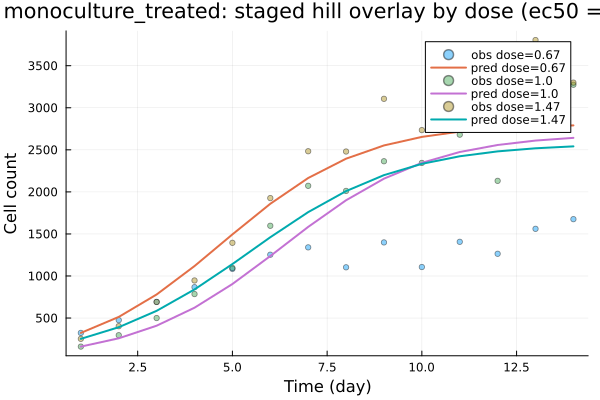

In [8]:
staged_overlay_plot = plot(
    xlabel = "Time (day)",
    ylabel = "Cell count",
    title = "$(condition): staged hill overlay by dose (ec50 = 1.0)",
    legend = :topright,
    )

if nrow(staged_overlay) == 0
    println("No staged overlay data available.")
else
    for dose in sort(unique(staged_overlay.dose))
        dose_df = sort(staged_overlay[staged_overlay.dose .== dose, :], :time)
        scatter!(staged_overlay_plot, dose_df.time, dose_df.observed; ms=3, alpha=0.45, label="obs dose=$(dose)")
        plot!(staged_overlay_plot, dose_df.time, dose_df.predicted; lw=2, label="pred dose=$(dose)")
    end
    display(staged_overlay_plot)
end

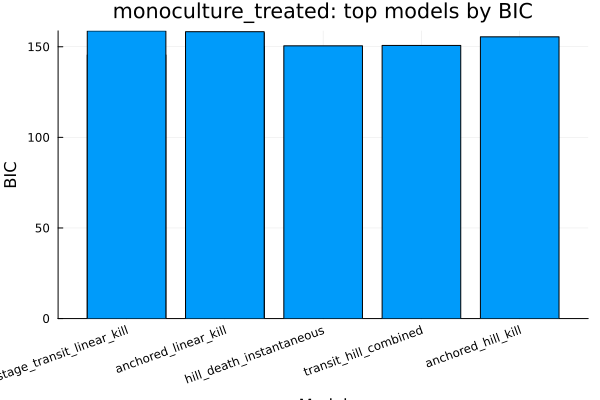

Overlay CSV is missing required columns: time, observed


In [9]:
# Visualize model quality (BIC) and model-vs-data overlay, when available
ranking_sorted = sort(fit_artifacts.ranking, :bic)
top_n = min(8, nrow(ranking_sorted))
bic_plot = bar(
    string.(ranking_sorted.model[1:top_n]),
    ranking_sorted.bic[1:top_n];
    legend = false,
    xlabel = "Model",
    ylabel = "BIC",
    title = "$(condition): top models by BIC",
    xrotation = 20,
)
display(bic_plot)

overlay_dir = joinpath(out.csv, "figures")
overlay_csvs = isdir(overlay_dir) ? sort(filter(f -> endswith(lowercase(f), "_overlay.csv"), readdir(overlay_dir; join = true))) : String[]

if isempty(overlay_csvs)
    println("No overlay CSV found in $(overlay_dir).")
else
    overlay = CSV.read(first(overlay_csvs), DataFrame)
    if !(:time in names(overlay) && :observed in names(overlay))
        println("Overlay CSV is missing required columns: time, observed")
    else
        p = scatter(
            overlay.time,
            overlay.observed;
            alpha = 0.4,
            ms = 3,
            color = :black,
            label = "observed",
            xlabel = "Time (day)",
            ylabel = "Cell count",
            title = "$(condition): model overlays",
        )

        pred_cols = filter(c -> startswith(String(c), "pred_"), names(overlay))
        plotted = 0
        for c in pred_cols
            mask = [!(ismissing(v) || (v isa AbstractFloat && isnan(v))) for v in overlay[!, c]]
            if any(mask)
                plot!(p, overlay.time[mask], overlay[mask, c]; lw = 2, label = replace(String(c), "pred_" => ""))
                plotted += 1
            end
        end

        if plotted == 0
            println("No non-missing model predictions found in overlay CSV.")
        end

        display(p)
    end
end

In [10]:
analysis_artifacts = MechanicalAutomaticModeling.AnalysisWorkflows.run_condition_analysis!(decoded, fit_artifacts, condition; start=@__DIR__)
Text(repr(analysis_artifacts.sensitivity))

1×2 DataFrame
 Row │ model                          note
     │ String                         String
─────┼──────────────────────────────────────────────────────────────────
   1 │ one_stage_transit_linear_kill  Sensitivity call not available w…

In [11]:
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
summary = DataFrame(
    condition = [condition],
    decoded_rows = [nrow(decoded)],
    fit_rows = [nrow(fit_artifacts.ranking)],
    sensitivity_rows = [nrow(analysis_artifacts.sensitivity)],
    generated_at = [Dates.format(now(UTC), dateformat"yyyy-mm-ddTHH:MM:SS")]
)
summary_path = joinpath(out.metrics, "$(condition)_automatic_summary.csv")
CSV.write(summary_path, summary)
MechanicalAutomaticModeling.IOUtils.write_manifest_row(condition=condition, step="summary", outputs=[summary_path], start=@__DIR__)
Text(repr(summary))

1×5 DataFrame
 Row │ condition            decoded_rows  fit_rows  sensitivity_rows  generated_at
     │ String               Int64         Int64     Int64             String
─────┼────────────────────────────────────────────────────────────────────────────────────
   1 │ monoculture_treated           504        33                 1  2026-04-28T02:58:38

## Final Plot: Best Fitted Model Over Data
This final cell overlays the best-BIC fitted model trajectory on top of the observed data and saves the figure to the condition image output folder.

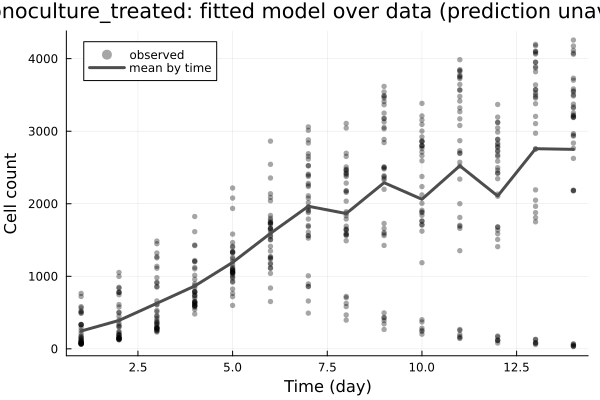

No finite fitted predictions found in overlay CSVs; plotting observed data only.
Saved: c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\outputs\images\monoculture_treated\monoculture_treated_notebook_best_fit_overlay.png


In [12]:
# Final overlay plot: best fitted model over observed data
ranking_sorted = sort(fit_artifacts.ranking, :bic)
best_model = String(ranking_sorted.model[1])
best_model_col_name = "pred_" * lowercase(best_model)

overlay_dir = joinpath(out.csv, "figures")
overlay_csvs = isdir(overlay_dir) ? sort(filter(f -> endswith(lowercase(f), "_overlay.csv"), readdir(overlay_dir; join = true))) : String[]

find_col(cols, candidates) = begin
    cand = Set(candidates)
    for c in cols
        lowercase(String(c)) in cand && return c
    end
    return nothing
end
finite_mask(vec) = [!(ismissing(v) || (v isa AbstractFloat && isnan(v))) for v in vec]

overlay = nothing
time_col = nothing
obs_col = nothing
pred_col = nothing
overlay_path = ""
selected_label = ""

for f in overlay_csvs
    df = CSV.read(f, DataFrame)
    tcol = find_col(names(df), ["time", "day", "days", "t"])
    ocol = find_col(names(df), ["observed", "count", "cell_count", "cells", "mean_count"])
    (tcol === nothing || ocol === nothing) && continue

    # First choice: best model prediction with finite values
    bcol = find_col(names(df), [best_model_col_name])
    if bcol !== nothing
        bmask = finite_mask(df[!, bcol])
        if any(bmask)
            overlay = df
            time_col = tcol
            obs_col = ocol
            pred_col = bcol
            overlay_path = f
            selected_label = "best model: $(best_model)"
            break
        end
    end

    # Fallback: any prediction column with finite values
    pred_candidates = filter(c -> startswith(lowercase(String(c)), "pred_"), names(df))
    for c in pred_candidates
        cmask = finite_mask(df[!, c])
        if any(cmask)
            overlay = df
            time_col = tcol
            obs_col = ocol
            pred_col = c
            overlay_path = f
            selected_label = "fallback: " * replace(String(c), "pred_" => "")
            break
        end
    end
    overlay !== nothing && break
end

if overlay === nothing
    println("No finite fitted predictions found in overlay CSVs; plotting observed data only.")
    best_fit_plot = scatter(
        decoded.time,
        decoded.count;
        alpha = 0.35,
        ms = 3,
        color = :black,
        label = "observed",
        xlabel = "Time (day)",
        ylabel = "Cell count",
        title = "$(condition): fitted model over data (prediction unavailable)",
        legend = :topleft,
    )
    time_means = combine(groupby(decoded, :time), :count => mean => :mean_count)
    plot!(best_fit_plot, time_means.time, time_means.mean_count; lw = 3, color = :gray30, label = "mean by time")
    best_overlay_path = joinpath(out.images, "$(condition)_notebook_best_fit_overlay.png")
    savefig(best_fit_plot, best_overlay_path)
    println("Saved: $(best_overlay_path)")
    display(best_fit_plot)
else
    best_fit_plot = scatter(
        overlay[!, time_col],
        overlay[!, obs_col];
        alpha = 0.4,
        ms = 3,
        color = :black,
        label = "observed",
        xlabel = "Time (day)",
        ylabel = "Cell count",
        title = "$(condition): fitted model over data",
        legend = :topleft,
    )
    pmask = finite_mask(overlay[!, pred_col])
    plot!(best_fit_plot, overlay[pmask, time_col], overlay[pmask, pred_col]; lw = 3, color = :crimson, label = selected_label)
    best_overlay_path = joinpath(out.images, "$(condition)_notebook_best_fit_overlay.png")
    savefig(best_fit_plot, best_overlay_path)
    println("Source overlay: $(overlay_path)")
    println("Prediction used: $(selected_label)")
    println("Saved: $(best_overlay_path)")
    display(best_fit_plot)
end